In [958]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [959]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 70
WINDOW_STRIDE_SAMPLES = 10
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [960]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [961]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [962]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [963]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        269628
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [964]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [965]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [966]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [967]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

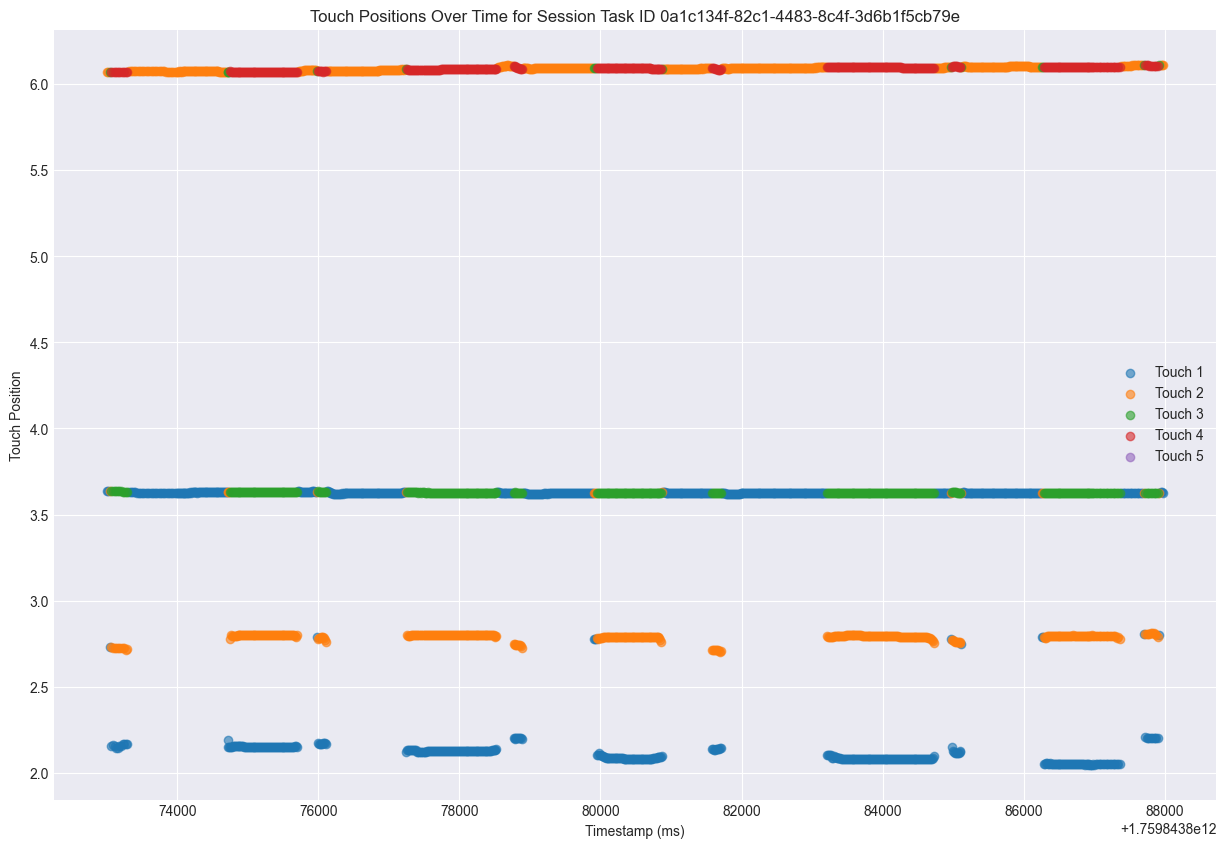

In [968]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [969]:
# Stabilize dataframe
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Stabilization Complete.


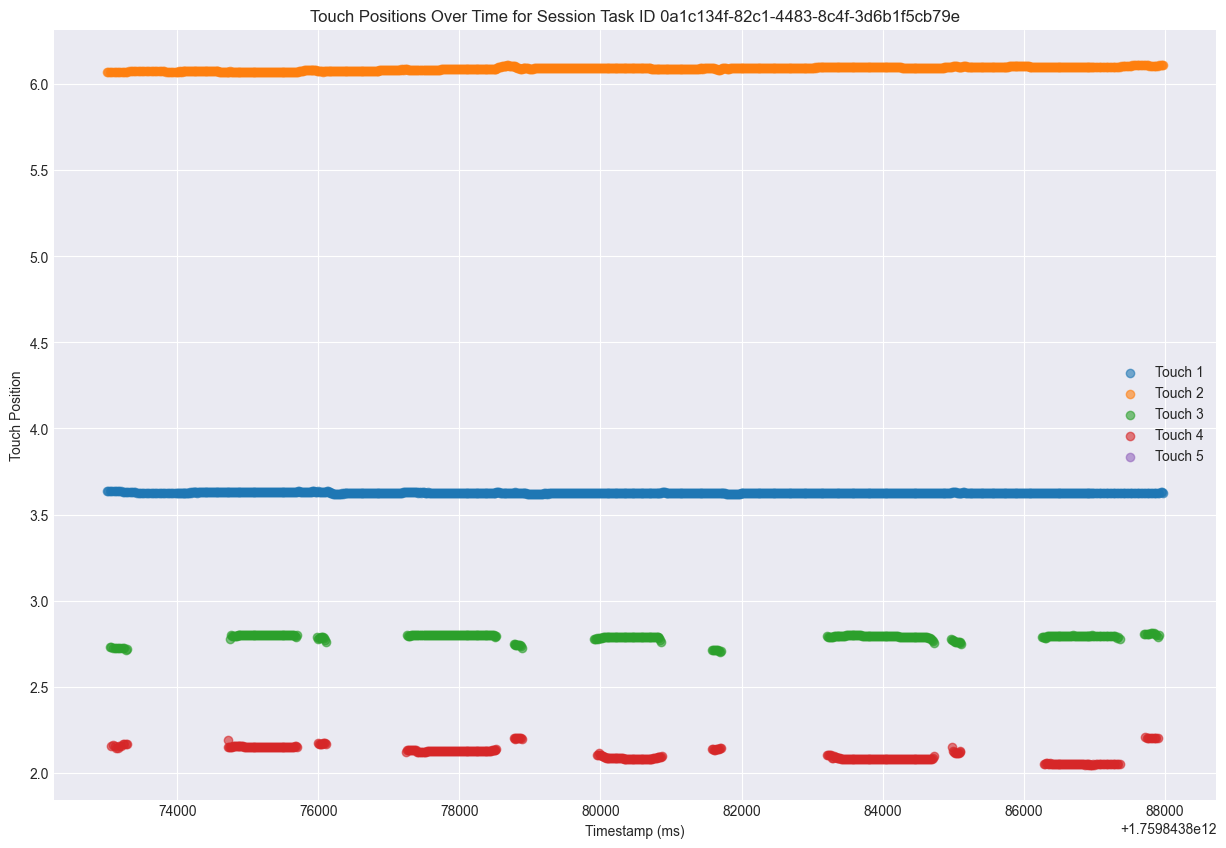

In [970]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [971]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(2, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    109132
touch_1_pressure    109132
touch_1_channel     109132
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            204519
dtype: int64

In [972]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")

Min samples per group_id: 8
Max samples per group_id: 469
Mean samples per group_id: 60.94
Parent gesture for group_id with max samples (262783cc-2cc2-42c8-aa98-25f2500ee1fe): No Gesture
Parent gesture for group_id with min samples (c87bb56f-29e0-4588-bca5-f869084d8315): Two-Finger Tap
Max samples for 'No Gesture' group_id: 469


In [973]:
# Per gesture, print the min and max size of groups
gesture_grouped = df_clean.groupby(['parent_gesture', 'group_id']).size().reset_index(name='size')
for gesture, group in gesture_grouped.groupby('parent_gesture'):
    min_non_zero_size = group[group['size'] > 0]['size'].min()
    max_size = group['size'].max()
    print(f"Gesture: {gesture}, Min samples in group: {min_non_zero_size}, Max samples in group: {max_size}")

Gesture: Double Tap, Min samples in group: 20, Max samples in group: 42
Gesture: No Gesture, Min samples in group: 9, Max samples in group: 469
Gesture: Single Tap, Min samples in group: 9, Max samples in group: 24
Gesture: Two-Finger Double Tap, Min samples in group: 22, Max samples in group: 55
Gesture: Two-Finger Opposite Double Tap, Min samples in group: 21, Max samples in group: 49
Gesture: Two-Finger Opposite Tap, Min samples in group: 9, Max samples in group: 28
Gesture: Two-Finger Tap, Min samples in group: 8, Max samples in group: 47


In [974]:
WINDOW_GESTURE_MAJORITY_THRESHOLD = 1 / grouped.min()
print(WINDOW_GESTURE_MAJORITY_THRESHOLD)

0.125


In [975]:
# Create sliding windows from the cleaned DataFrame
X_windows = []
y_windows = []
meta_data = []

# did_print = 0

print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values
    is_gesture = group['is_gesture'].values

    # Does any of the gestures in this group end with a "Tap"
    includesATapGesture = np.any(is_gesture == 1)
    
    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE_SAMPLES + 1, WINDOW_STRIDE_SAMPLES):
        # if includesATapGesture:
        #     did_print += 1

        end = start + WINDOW_SIZE_SAMPLES
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]

        majority_label = "No Gesture"
        # If there is a a gesture fully shown in this window (meaning there is is_gesture == 0, is_gesture == 1 and is_gesture == 0 again)
        gesture_indices = np.where(is_gesture[start:end] == 1)[0]
        if len(gesture_indices) > 0:
            first_gesture_index = gesture_indices[0]
            last_gesture_index = gesture_indices[-1]
            if first_gesture_index > 0 and last_gesture_index < WINDOW_SIZE_SAMPLES - 1:
                majority_label = window_labels[first_gesture_index]
        # else:
        #     # Otherwise, use majority voting if above threshold
        #     label_counts = pd.Series(window_labels).value_counts(normalize=True)
        #     top_label = label_counts.idxmax()
        #     top_label_ratio = label_counts.max()
        #     if top_label_ratio >= WINDOW_GESTURE_MAJORITY_THRESHOLD and top_label != 'No Gesture':
        #         majority_label = top_label

        # if did_print < 20 and majority_label != 'No Gesture' and includesATapGesture:
        #     # Draw a graph of all touch positions for this session_task_id
        #     plt.figure(figsize=(15, 10))
        #     for touch_num in range(1, 6):
        #         plt.scatter(
        #             group["timestamp_ms"].values[start:end],
        #             group[f"touch_{touch_num}_position"].values[start:end],
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Timestamp (ms)")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Session Task ID {session_task_id} with majority label '{majority_label}'")
        #     plt.legend()
        #     plt.show() 

        if majority_label == 'No Gesture':
            continue
        
        X_windows.append(window_data)
        y_windows.append(majority_label)
        meta_data.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
        })
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_data_df = pd.DataFrame(meta_data)
print(f"Created {X_windows.shape[0]} windows of size {WINDOW_SIZE_SAMPLES} samples.")
# Display the shape of the created windows
X_windows.shape, y_windows.shape, meta_data_df.shape


Creating sliding windows...
Created 1920 windows of size 70 samples.


((1920, 70, 17), (1920,), (1920, 4))

In [976]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
Double Tap: 286
Single Tap: 373
Two-Finger Double Tap: 248
Two-Finger Opposite Double Tap: 253
Two-Finger Opposite Tap: 356
Two-Finger Tap: 404


In [977]:
def extract_features(window, is_padded_window):
    # 1. SETUP & INITIALIZATION
    features = []
    feature_names = []
    
    # Indices based on your sensor layout
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]
    touch_pressure_cols = [3, 6, 9, 12, 15]
    touch_position_cols = [2, 5, 8, 11, 14]
    original_length_col = window.shape[1] - 1 # Assuming it's the last column
    
    # Required for the continuous touch logic
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    def circular_range(angles):
        if len(angles) == 0: return 0
        sorted_angles = np.sort(angles)
        gaps = np.diff(sorted_angles)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        all_gaps = np.append(gaps, wrap_gap)
        return 2 * np.pi - np.max(all_gaps)

    # 2. PRE-PROCESSING: Zero out inactive fingers
    # We work on a copy to avoid mutating the original window if it's used elsewhere
    working_window = window.copy()
    
    for i in range(len(touch_position_cols)):
        pos_idx = touch_position_cols[i]
        press_idx = touch_pressure_cols[i]
        chan_idx = touch_channel_cols[i]
        
        f_pressures = working_window[:, press_idx]
        f_positions = np.nan_to_num(working_window[:, pos_idx], nan=0.0)
        
        is_touching = f_pressures > 0
        
        if np.any(is_touching):
            # Calculate movement
            valid_positions = f_positions[is_touching]
            c_range = circular_range(valid_positions)
            has_moved = c_range > TOUCH_MOVE_THRESHOLD
            
            # Calculate continuity
            start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
            end_of_touches = is_touching & ~np.append(is_touching[1:], False)
            touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
            min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
            is_continuous_touch = min_touch_duration >= original_length - 1
            
            # THE LOGIC: If not active/moving, zero out the finger data
            is_active = (has_moved or not is_continuous_touch)
            if not is_active:
                working_window[:, [pos_idx, press_idx, chan_idx]] = 0
        else:
            # If never touching, ensure it's 0
            working_window[:, [pos_idx, press_idx, chan_idx]] = 0

    # 3. FEATURE EXTRACTION (Now using working_window)
    touch_pressures = working_window[:, touch_pressure_cols]
    touch_positions_all = working_window[:, touch_position_cols]
    
    # Mask for centroid/spread calculations
    valid_mask = touch_pressures > 0
    touch_positions_flat = touch_positions_all[valid_mask]

    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # General Touch Activity Features
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    add_feature("any_touch", np.any(active_touches))
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    add_feature("max_pressure", np.max(touch_pressures))
    
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)

    # --- Distances between fingers (using filtered working_window) ---
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    dist_idx = 0
    for p1_idx, p2_idx in combinations(range(5), 2):
        dist_idx += 1
        f1_pos = working_window[:, touch_position_cols[p1_idx]]
        f2_pos = working_window[:, touch_position_cols[p2_idx]]
        f1_press = working_window[:, touch_pressure_cols[p1_idx]]
        f2_press = working_window[:, touch_pressure_cols[p2_idx]]
        
        valid_dist_mask = (f1_press > 0) & (f2_press > 0)
        distances = short_dist(f1_pos[valid_dist_mask], f2_pos[valid_dist_mask])

        # Split the distances in 5 equal bins and get the distance values per bin for better time perception
        distance_parts = np.array_split(distances, 5)
        for bin_idx, part in enumerate(distance_parts):
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_mean", np.mean(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_max", np.max(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_min", np.min(part) if len(part) > 0 else 0)

        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{dist_idx}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q75", np.percentile(distances, 75) if has_distance else 0)

    # --- Per Finger Features ---
    amount_active_moving_fingers = 0
    for i in range(len(touch_position_cols)):
        finger_positions = working_window[:, touch_position_cols[i]]
        finger_pressures = working_window[:, touch_pressure_cols[i]]
        finger_channels = working_window[:, touch_channel_cols[i]]

        is_touching = finger_pressures > 0
        # Re-calculating these for the specific finger features
        circle_range = circular_range(finger_positions[is_touching]) if np.any(is_touching) else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        
        # Continuity check for the count
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        is_continuous_touch = min_touch_duration >= original_length - 1

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)

    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [978]:
le = LabelEncoder()
y_windows_encoded = le.fit_transform(y_windows)

In [979]:
# Print nan for both datasets before feature extraction
print(f"NaN in windows before feature extraction: {np.isnan(X_windows).any()}")

NaN in windows before feature extraction: True


In [980]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_windows_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_windows_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (1920, 313)


In [981]:
# Print nan for both datasets after feature extraction
print(f"NaN in windows after feature extraction: {np.isnan(X_windows_extracted).any()}")

NaN in windows after feature extraction: True


In [982]:
# Set all nan values to 0
X_win = np.nan_to_num(X_windows_extracted, nan=0.0)

In [983]:
# Lets visualize the X_sequences for the "Double Tap" gesture
gesture_name = "Two-Finger Double Tap"
print("Values for gesture:", gesture_name)
gesture_index = np.where(le.classes_ == gesture_name)[0][0]
indices = np.where(y_windows_encoded == gesture_index)[0]
if len(indices) == 0:
    print(f"No samples found for gesture: {gesture_name}")
else:
    sample_index = indices[0]
    sample_features = X_win[sample_index]

    # Print the values with the feature name for this row
    for fname, fvalue in zip(feature_names, sample_features):
        print(f"{fname}: {fvalue}")

Values for gesture: Two-Finger Double Tap
max_simultaneous_touches: 2.0
avg_active_touches: 1.3428571224212646
any_touch: 1.0
total_active_touch_samples: 94.0
total_pressure: 81789.0
max_pressure: 1066.0
min_non_zero_pressure: 45.0
finger_distance_1_bin_1_mean: 0.0
finger_distance_1_bin_1_max: 0.0
finger_distance_1_bin_1_min: 0.0
finger_distance_1_bin_2_mean: 0.0
finger_distance_1_bin_2_max: 0.0
finger_distance_1_bin_2_min: 0.0
finger_distance_1_bin_3_mean: 0.0
finger_distance_1_bin_3_max: 0.0
finger_distance_1_bin_3_min: 0.0
finger_distance_1_bin_4_mean: 0.0
finger_distance_1_bin_4_max: 0.0
finger_distance_1_bin_4_min: 0.0
finger_distance_1_bin_5_mean: 0.0
finger_distance_1_bin_5_max: 0.0
finger_distance_1_bin_5_min: 0.0
finger_distance_1_mean: 0.0
finger_distance_1_max: 0.0
finger_distance_1_min: 0.0
finger_distance_1_q25: 0.0
finger_distance_1_q75: 0.0
finger_distance_2_bin_1_mean: 0.0
finger_distance_2_bin_1_max: 0.0
finger_distance_2_bin_1_min: 0.0
finger_distance_2_bin_2_mean: 0.

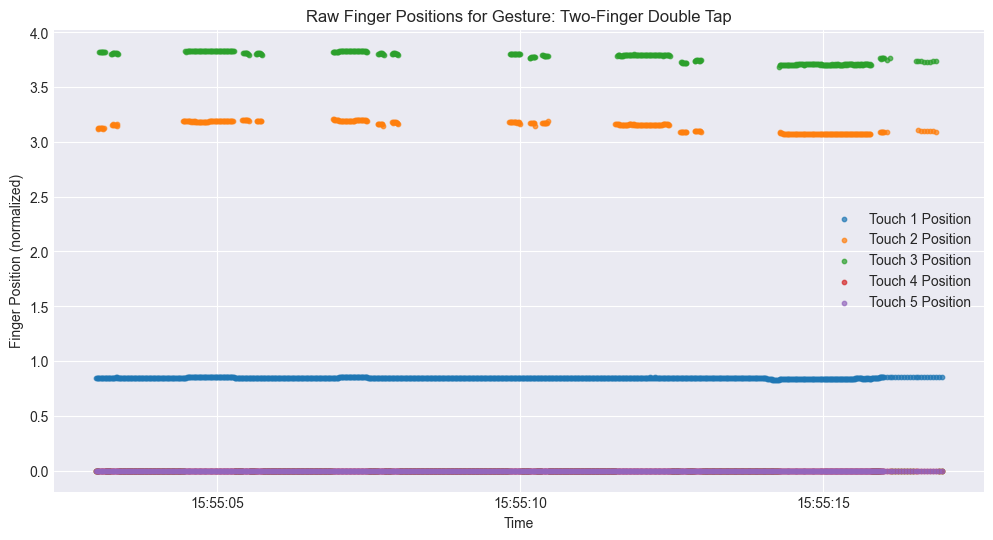

In [984]:
# Draw a graph of the raw finger position data for the same sample
raw_sample = df_clean[
    df_clean["session_task_id"] == meta_data_df.iloc[indices[0]]["session_task_id"]
]

plt.figure(figsize=(12, 6))

for i in range(5):
    pos_col = f'touch_{i+1}_position'
    plt.scatter(
        raw_sample['estimated_timestamp'],
        raw_sample[pos_col],
        s=10,        # point size
        alpha=0.7,   # transparency to reduce overplotting
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Raw Finger Positions for Gesture: {gesture_name}')
plt.legend()
plt.show()

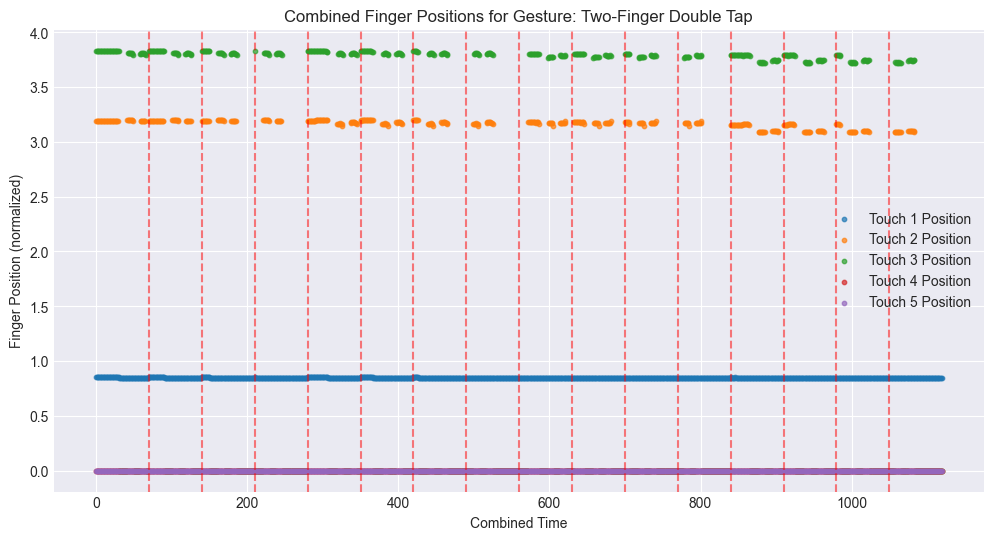

In [985]:
# Draw a graph of the finger positions for all windows that was classified as the gesture, as if they where performed right after one another, with vertical colored lines indicating the window boundaries
plt.figure(figsize=(12, 6))

indices_checked = set()
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []

    for idx in indices:
        window_start = meta_data_df.iloc[idx]['start_index']
        window_end = meta_data_df.iloc[idx]['end_index']
        session_id = meta_data_df.iloc[idx]['session_task_id']

        # continue if the session_task_id is not in raw_sample
        if session_id not in raw_sample['session_task_id'].values:
            continue

        # add to indices checekd
        indices_checked.add(idx)

        window_data = df_clean[
            df_clean['session_task_id'] == session_id
        ].iloc[window_start:window_end]

        combined_positions.extend(window_data[pos_col].values)

    combined_positions = np.array(combined_positions)
    x = np.arange(len(combined_positions))

    plt.scatter(
        x,
        combined_positions,
        s=10,              # marker size (adjust as needed)
        alpha=0.7,
        label=f'Touch {i+1} Position'
    )

plt.xlabel('Combined Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Combined Finger Positions for Gesture: {gesture_name}')

# Draw vertical lines for window boundaries
for w in range(1, len(indices_checked)):
    plt.axvline(
        x=w * WINDOW_SIZE_SAMPLES,
        color='red',
        linestyle='--',
        alpha=0.5
    )

plt.legend()
plt.show()

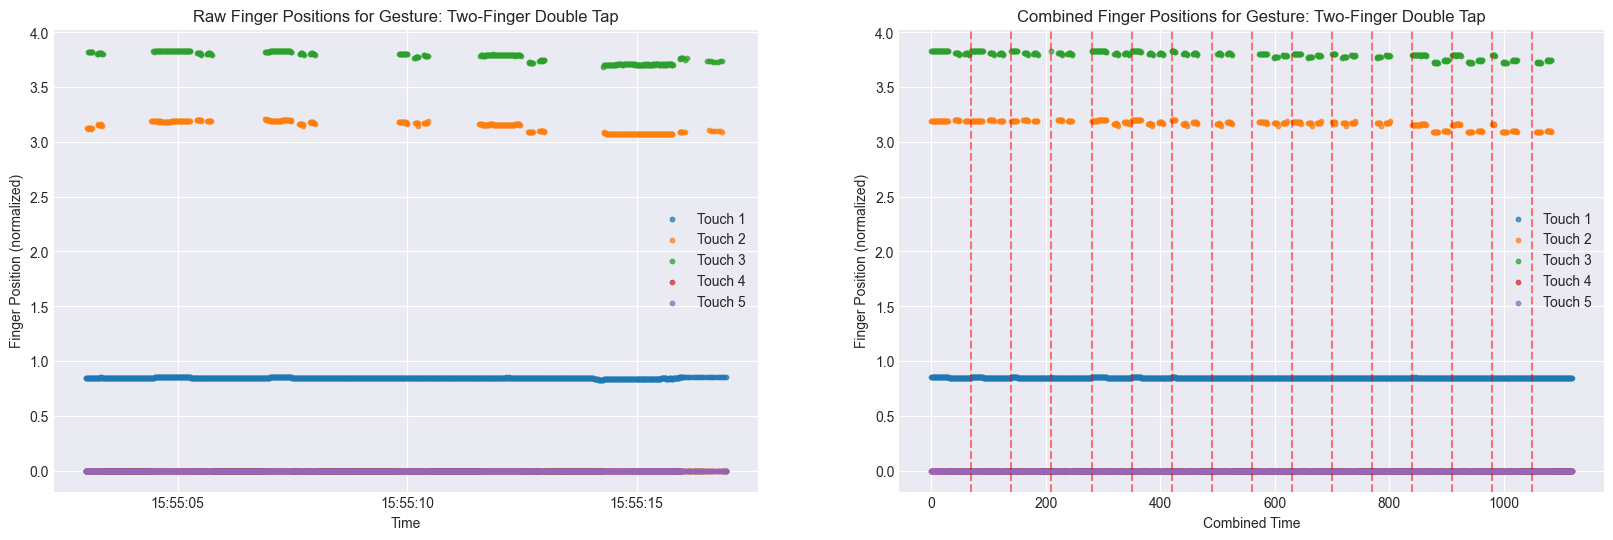

In [986]:
# draw the two graphs side by side
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
# Left graph: Raw finger positions
axs[0].set_title(f'Raw Finger Positions for Gesture: {gesture_name}')
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    axs[0].scatter(
        raw_sample['estimated_timestamp'],
        raw_sample[pos_col],
        s=10,        # point size
        alpha=0.7,   # transparency to reduce overplotting
        label=f'Touch {i+1}'
    )
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Finger Position (normalized)')
axs[0].legend()
# Right graph: Combined finger positions
axs[1].set_title(f'Combined Finger Positions for Gesture: {gesture_name}')
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []

    for idx in indices:
        window_start = meta_data_df.iloc[idx]['start_index']
        window_end = meta_data_df.iloc[idx]['end_index']
        session_id = meta_data_df.iloc[idx]['session_task_id']

        # continue if the session_task_id is not in raw_sample
        if session_id not in raw_sample['session_task_id'].values:
            continue

        window_data = df_clean[
            df_clean['session_task_id'] == session_id
        ].iloc[window_start:window_end]

        combined_positions.extend(window_data[pos_col].values)

    combined_positions = np.array(combined_positions)
    x = np.arange(len(combined_positions))

    axs[1].scatter(
        x,
        combined_positions,
        s=10,              # marker size (adjust as needed)
        alpha=0.7,
        label=f'Touch {i+1}'
    )
axs[1].set_xlabel('Combined Time')
axs[1].set_ylabel('Finger Position (normalized)')
# Draw vertical lines for window boundaries
for w in range(1, len(indices_checked)):
    axs[1].axvline(
        x=w * WINDOW_SIZE_SAMPLES,
        color='red',
        linestyle='--',
        alpha=0.5
    )
axs[1].legend()
plt.show()

In [987]:
participant_ids = meta_data_df['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 2]
val_pids = participant_ids[amount_of_participants - 2:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

print(f"Amount of participants: {amount_of_participants} (Train: {len(train_pids)}, Val: {len(val_pids)}, Test: {len(test_pids)})")

Amount of participants: 8 (Train: 6, Val: 1, Test: 1)


In [988]:
# Split sliding windows
train_mask_win = meta_data_df['participant_id'].isin(train_pids)
X_train_win = X_win[train_mask_win]
y_train_win = y_windows_encoded[train_mask_win]

val_mask_win = meta_data_df['participant_id'].isin(val_pids)
X_val_win = X_win[val_mask_win]
y_val_win = y_windows_encoded[val_mask_win]

test_mask_win = meta_data_df['participant_id'].isin(test_pids)
X_test_win = X_win[test_mask_win]
y_test_win = y_windows_encoded[test_mask_win]

In [989]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train_win == label_int)
    val_count = np.sum(y_val_win == label_int)
    test_count = np.sum(y_test_win == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: Double Tap | Train: 223 | Val: 29 | Test: 34
Label: Single Tap | Train: 281 | Val: 42 | Test: 50
Label: Two-Finger Double Tap | Train: 205 | Val: 6 | Test: 37
Label: Two-Finger Opposite Double Tap | Train: 202 | Val: 24 | Test: 27
Label: Two-Finger Opposite Tap | Train: 269 | Val: 47 | Test: 40
Label: Two-Finger Tap | Train: 321 | Val: 40 | Test: 43


In [990]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Sliding Window Split:")
print(f"  X_train_win: {X_train_win.shape}, y_train_win: {y_train_win.shape}")
print(f"  X_val_win:   {X_val_win.shape},   y_val_win:   {y_val_win.shape}")
print(f"  X_test_win:  {X_test_win.shape},  y_test_win:  {y_test_win.shape}")

Sliding Window Split:
  X_train_win: (1501, 313), y_train_win: (1501,)
  X_val_win:   (188, 313),   y_val_win:   (188,)
  X_test_win:  (231, 313),  y_test_win:  (231,)


In [991]:
# Scale both datasets
scaler = StandardScaler()
X_train_win = scaler.fit_transform(X_train_win)
X_val_win = scaler.transform(X_val_win)
X_test_win = scaler.transform(X_test_win)

In [992]:
# CV Training
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.svm import LinearSVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.naive_bayes import GaussianNB

# MODEL_CONFIGS = [
#     {
#         "name": "RandomForest",
#         "pipeline": Pipeline([
#             ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
#         ]),
#         "param_grid": {
#             "clf__n_estimators":      [50, 200, 400, 800],
#             "clf__max_depth":         [None, 10, 20, 30],
#             "clf__min_samples_split": [2, 5, 10],
#             "clf__min_samples_leaf":  [1, 2, 4],
#             "clf__max_features":      ["sqrt", "log2", 0.5],
#             "clf__class_weight":      [None, "balanced"],
#         },
#     },
#     {
#         "name": "KNN",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", KNeighborsClassifier())
#         ]),
#         "param_grid": {
#             "clf__n_neighbors": [3, 5, 9],
#             "clf__weights": ["uniform", "distance"],
#             "clf__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
#         },
#     },
#     {
#         "name": "ExtraTrees",
#         "pipeline": Pipeline([
#             ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
#         ]),
#         "param_grid": {
#             "clf__n_estimators":      [50, 200, 400, 800],
#             "clf__max_depth":         [None, 10, 20, 30],
#             "clf__min_samples_split": [2, 5, 10],
#             "clf__min_samples_leaf":  [1, 2, 4],
#             "clf__max_features":      ["sqrt", "log2", 0.5],
#             "clf__class_weight":      [None, "balanced"],
#         },
#     },
#     {
#         "name": "LinearSVC",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", LinearSVC(
#                 max_iter=5000,
#                 dual=False
#             ))
#         ]),
#         "param_grid": {
#             "clf__C": [0.1, 1.0, 10.0],
#             "clf__class_weight": [None, "balanced"],
#         },
#     },
#     {
#         "name": "AdaBoost",
#         "pipeline": Pipeline([
#             ("clf", AdaBoostClassifier(random_state=42))
#         ]),
#         "param_grid": {
#             "clf__n_estimators": [50, 100, 200],
#             "clf__learning_rate": [0.01, 0.1, 1.0],
#         },
#     },
#     {
#         "name": "GaussianNB",
#         "pipeline": Pipeline([
#             ("scaler", StandardScaler()),
#             ("clf", GaussianNB())
#         ]),
#         "param_grid": {
#             # No hyperparameters to tune for GaussianNB
#         },
#     }
# ]


In [993]:
# CV Training
# from sklearn.model_selection import GroupKFold, GridSearchCV

# SCORING = "f1_macro"
# gkf = GroupKFold(n_splits=amount_of_participants-2)
# groups_train = meta_data_df[train_mask_win]["participant_id"].values

# best_model = None
# best_model_name = None
# best_score = -np.inf
# all_results = []

# for cfg in MODEL_CONFIGS:
#     name = cfg["name"]
#     pipe = cfg["pipeline"]
#     param_grid = cfg["param_grid"]

#     print(f"\n=== Tuning {name} ===")
#     grid = GridSearchCV(
#         estimator=pipe,
#         param_grid=param_grid,
#         cv=gkf,
#         scoring=SCORING,
#         n_jobs=-1,
#         verbose=2
#     )
#     grid.fit(X_train_win, y_train_win, groups=groups_train)

#     print(f"{name} best params: {grid.best_params_}")
#     print(f"{name} best CV {SCORING}: {grid.best_score_:.4f}")

#     all_results.append({
#         "model": name,
#         "best_score": grid.best_score_,
#         "best_params": grid.best_params_,
#         "estimator": grid.best_estimator_,
#     })

#     if grid.best_score_ > best_score:
#         best_score = grid.best_score_
#         best_model = grid.best_estimator_
#         best_model_name = name

# print("\n=== Summary over all models ===")
# for res in all_results:
#     print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

# print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")


In [994]:
# Random Training
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800), # Sample any integer between 50-800
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "KNN",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": randint(3, 15),
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800),
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    }
]

In [995]:
# Random Training
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

SCORING = "f1_macro"
gkf = GroupKFold(n_splits=amount_of_participants-2)
groups_train = meta_data_df[train_mask_win]["participant_id"].values

best_model = None
best_model_name = None
best_score = -np.inf
all_results = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]
    param_grid = cfg["param_grid"]

    print(f"\n=== Tuning {name} with RandomizedSearch ===")
    
    # RandomizedSearchCV picks a fixed number of settings (n_iter)
    # rather than trying every single combination.
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid, # Note: grid becomes distributions
        n_iter=30,                     # Adjust this! Higher = better, but slower
        cv=gkf,
        scoring=SCORING,
        n_jobs=-1,
        verbose=1,                     # Reduced verbosity slightly
        random_state=42                # Essential for reproducibility
    )
    
    search.fit(X_train_win, y_train_win, groups=groups_train)

    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV {SCORING}: {search.best_score_:.4f}")

    all_results.append({
        "model": name,
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "estimator": search.best_estimator_,
    })

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name

print("\n=== Summary over all models ===")
for res in all_results:
    print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")



=== Tuning RandomForest with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
RandomForest best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 539}
RandomForest best CV f1_macro: 0.8760

=== Tuning KNN with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
KNN best params: {'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'uniform'}
KNN best CV f1_macro: 0.7506

=== Tuning ExtraTrees with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
ExtraTrees best params: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 650}
ExtraTrees best CV f1_macro: 0.9288

=== Summary over all models ===
RandomForest: f1_macro=0.8760
KNN: f1_macro=0.7506
ExtraTrees: f1_macro=0.9288


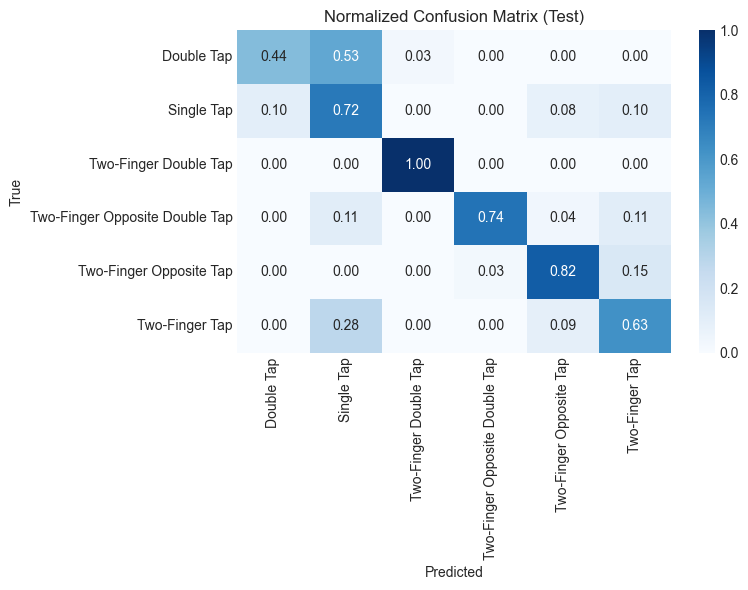

In [996]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test_win)

# print("Test classification report:\n",
#       classification_report(y_test_win, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_win, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [997]:
# Print which features are the most influencial for the best model if possible
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    print("\nTop 50 Feature Importances:")
    for fname, importance in feature_importance_pairs[:50]:
        print(f"{fname}: {importance:.4f}")


Top 50 Feature Importances:
finger_2_touch_reactivations: 0.0976
finger_3_touch_reactivations: 0.0954
finger_4_touch_reactivations: 0.0879
finger_3_touch_starts: 0.0419
finger_3_touch_ends: 0.0360
finger_1_touch_reactivations: 0.0194
finger_2_touch_starts: 0.0169
finger_2_touch_ends: 0.0168
finger_2_non_continuous_touch_duration: 0.0138
finger_2_positions_range: 0.0127
finger_4_touch_ends: 0.0108
finger_1_touch_starts: 0.0103
finger_1_touch_ends: 0.0098
finger_4_touch_starts: 0.0097
finger_2_positions_std: 0.0087
finger_distance_2_min: 0.0083
finger_3_positions_range: 0.0081
finger_distance_2_bin_4_min: 0.0072
finger_3_continuous_touch_duration: 0.0072
finger_distance_1_bin_2_min: 0.0070
finger_3_is_continuous_touch: 0.0068
finger_distance_1_bin_3_min: 0.0068
finger_distance_1_max: 0.0067
finger_distance_1_bin_4_min: 0.0067
finger_distance_2_max: 0.0066
finger_distance_1_bin_3_mean: 0.0065
finger_distance_1_bin_3_max: 0.0065
finger_distance_2_q25: 0.0065
finger_distance_1_bin_1_min: 0

In [998]:
import re
from collections import defaultdict

# Regex patterns
PATTERNS = [
    # finger_X_yyy_bucket_Z
    re.compile(r"^finger_(?P<finger>\d+)_(?P<feature>.+?)_\d+$"),
    # finger_X_yyy
    re.compile(r"^finger_(?P<finger>\d+)_(?P<feature>.+)$"),
    # finger_distance_yyy_X_bucket_Z
    re.compile(r"^finger_distance_(?P<finger>\d+)_(?P<feature>.+?)_\d+$"),
    # finger_distance_yyy_X
    re.compile(r"^finger_distance_(?P<finger>\d+)_(?P<feature>.+?)$"),
]

PATTERN_NAMES = [
    "Finger Feature Bucket",
    "Finger Feature",
    "Finger Distance Feature Bucket",
    "Finger Distance Feature",
]


def parse_feature_name(name):
    for idx, pattern in enumerate(PATTERNS):
        match = pattern.match(name)
        if match:
            return match.groupdict(), idx
    return None, -1


def aggregate_feature_importances(feature_importance_pairs):
    """
    Aggregates by (finger, feature_name)
    Buckets and distance variants are merged.
    """
    aggregated = defaultdict(float)

    for fname, importance in feature_importance_pairs:
        parsed, pattern_idx = parse_feature_name(fname)
        if parsed is None:
            # fallback: keep original name
            aggregated[fname] += importance
            continue

        key = parsed["feature"]
        pattern_name = PATTERN_NAMES[pattern_idx]
        aggregated[pattern_name + " " + key] += importance

    return dict(aggregated)

aggregated_importances = aggregate_feature_importances(feature_importance_pairs)
# Sort aggregated importances
sorted_aggregated = sorted(aggregated_importances.items(), key=lambda x: x[1], reverse=True)
print("\nTop 50 Aggregated Feature Importances:")
for feature, importance in sorted_aggregated[:50]:
    print(f"{feature}: {importance:.4f}")


Top 50 Aggregated Feature Importances:
Finger Feature touch_reactivations: 0.3003
Finger Feature touch_starts: 0.0787
Finger Feature touch_ends: 0.0734
Finger Feature non_continuous_touch_duration: 0.0254
Finger Feature positions_range: 0.0234
Finger Distance Feature min: 0.0233
Finger Distance Feature bin_4_min: 0.0214
Finger Distance Feature max: 0.0203
Finger Distance Feature q25: 0.0202
Finger Distance Feature bin_2_min: 0.0202
Finger Distance Feature bin_3_mean: 0.0201
Finger Distance Feature q75: 0.0199
Finger Distance Feature bin_1_max: 0.0199
Finger Distance Feature bin_1_min: 0.0199
Finger Distance Feature bin_3_max: 0.0195
Finger Distance Feature mean: 0.0193
Finger Distance Feature bin_4_max: 0.0190
Finger Distance Feature bin_2_max: 0.0185
Finger Distance Feature bin_3_min: 0.0183
Finger Distance Feature bin_2_mean: 0.0182
Finger Distance Feature bin_4_mean: 0.0169
Finger Distance Feature bin_1_mean: 0.0167
Finger Distance Feature bin_5_min: 0.0157
Finger Distance Feature 

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 256)            │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,926 (476.27 KB)

 Trainable params: 121,926 (476.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
47/47 - 1s - 16ms/step - accuracy: 0.4730 - loss: 1.2211 - val_accuracy: 0.5213 - val_loss: 1.1157
Epoch 2/100
47/47 - 0s - 3ms/step - accuracy: 0.7115 - loss: 0.6577 - val_accuracy: 0.6170 - val_loss: 0.9941
Epoch 3/100
47/47 - 0s - 3ms/step - accuracy: 0.8235 - loss: 0.4219 - val_accuracy: 0.6330 - val_loss: 0.8236
Epoch 4/100
47/47 - 0s - 3ms/step - accuracy: 0.8881 - loss: 0.2810 - val_accuracy: 0.6968 - val_loss: 0.6241
Epoch 5/100
47/47 - 0s - 3ms/step - accuracy: 0.9227 - loss: 0.2063 - val_accuracy: 0.7074 - val_loss: 0.5399
Epoch 6/100
47/47 - 0s - 2ms/step - accuracy: 0.9247 - loss: 0.1879 - val_accuracy: 0.8191 - val_loss: 0.5509
Epoch 7/100
47/47 - 0s - 3ms/step - accuracy: 0.9520 - loss: 0.1244 - val_accuracy: 0.7074 - val_loss: 0.8339
Epoch 8/100
47/47 - 0s - 2ms/step - accuracy: 0.9540 - loss: 0.1230 - val_accuracy: 0.8457 - val_loss: 0.7878
Epoch 9/100
47/47 - 0s - 2ms/step - accuracy: 0.9594 - loss: 0.1060 - val_accuracy: 0.7287 - val_loss: 0.7541
Epoch 10/

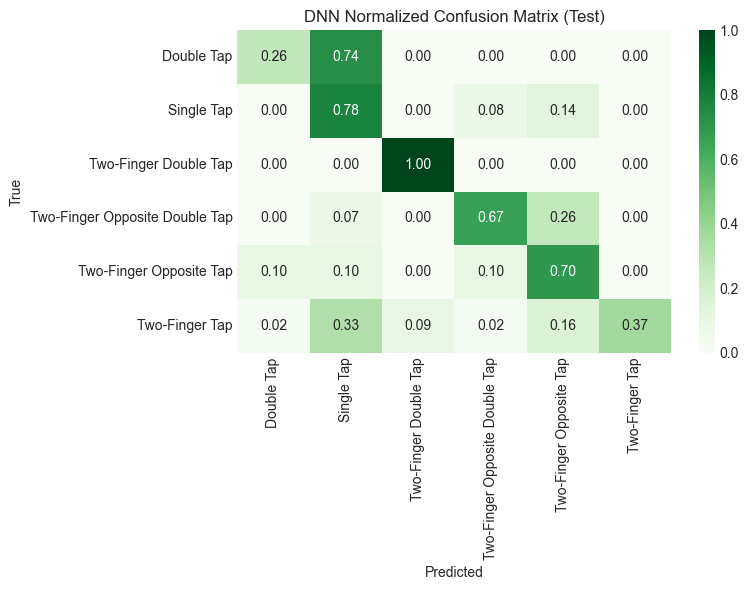

In [999]:
# Drain a DNN on the same data for comparison
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_dnn_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_model = create_dnn_model(input_shape=(X_train_win.shape[1],), num_classes=len(le.classes_))
dnn_model.summary()
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = dnn_model.fit(
    X_train_win, y_train_win,
    validation_data=(X_val_win, y_val_win),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)
# Evaluate on test set
test_loss, test_accuracy = dnn_model.evaluate(X_test_win, y_test_win, verbose=0)
print(f"DNN Test Accuracy: {test_accuracy:.4f}")

y_test_dnn_pred_probs = dnn_model.predict(X_test_win)
y_test_dnn_pred = np.argmax(y_test_dnn_pred_probs, axis=1)
print("DNN Test classification report:\n",
      classification_report(y_test_win, y_test_dnn_pred, target_names=le.classes_))

cm_dnn = confusion_matrix(y_test_win, y_test_dnn_pred)
cm_dnn_norm = cm_dnn.astype("float") / cm_dnn.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()
        

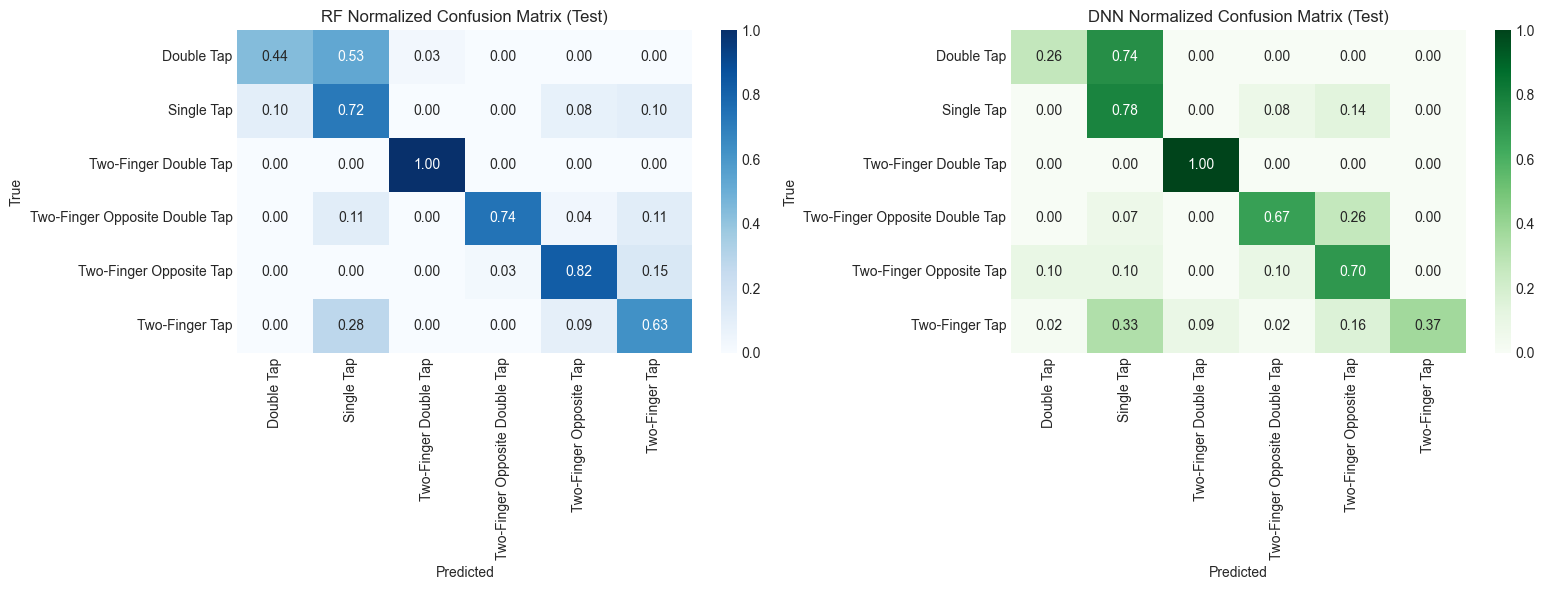

In [1000]:
# compare the confusion matrixes and show a plot comparing both models
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Normalized Confusion Matrix (Test)")
plt.subplot(1, 2, 2)
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()